
--- VALORES ASIGNADOS EN LOS PUNTOS NULOS ---
            Real      Lineal      Spline   Polinomic  RandomWalk
Month                                                           
1949-12-01   118  111.333333  101.443309  101.020193   77.681723
1950-01-01   115  118.666667  109.339082  110.320954   49.196608
1950-07-01   170  152.000000  169.292611  166.401205  143.918838
1950-08-01   170  155.000000  174.463086  170.078098  111.327132
1951-04-01   163  175.000000  182.878572  180.839381  183.079651
1953-04-01   235  232.500000  240.488383  239.518609  232.171547
1953-09-01   237  241.500000  249.446834  249.209555  360.892853
1954-05-01   234  243.500000  232.571209  231.142006  192.398794
1954-06-01   264  260.000000  261.352685  264.994498  166.001331
1954-07-01   302  276.500000  288.858537  295.808086  180.311225


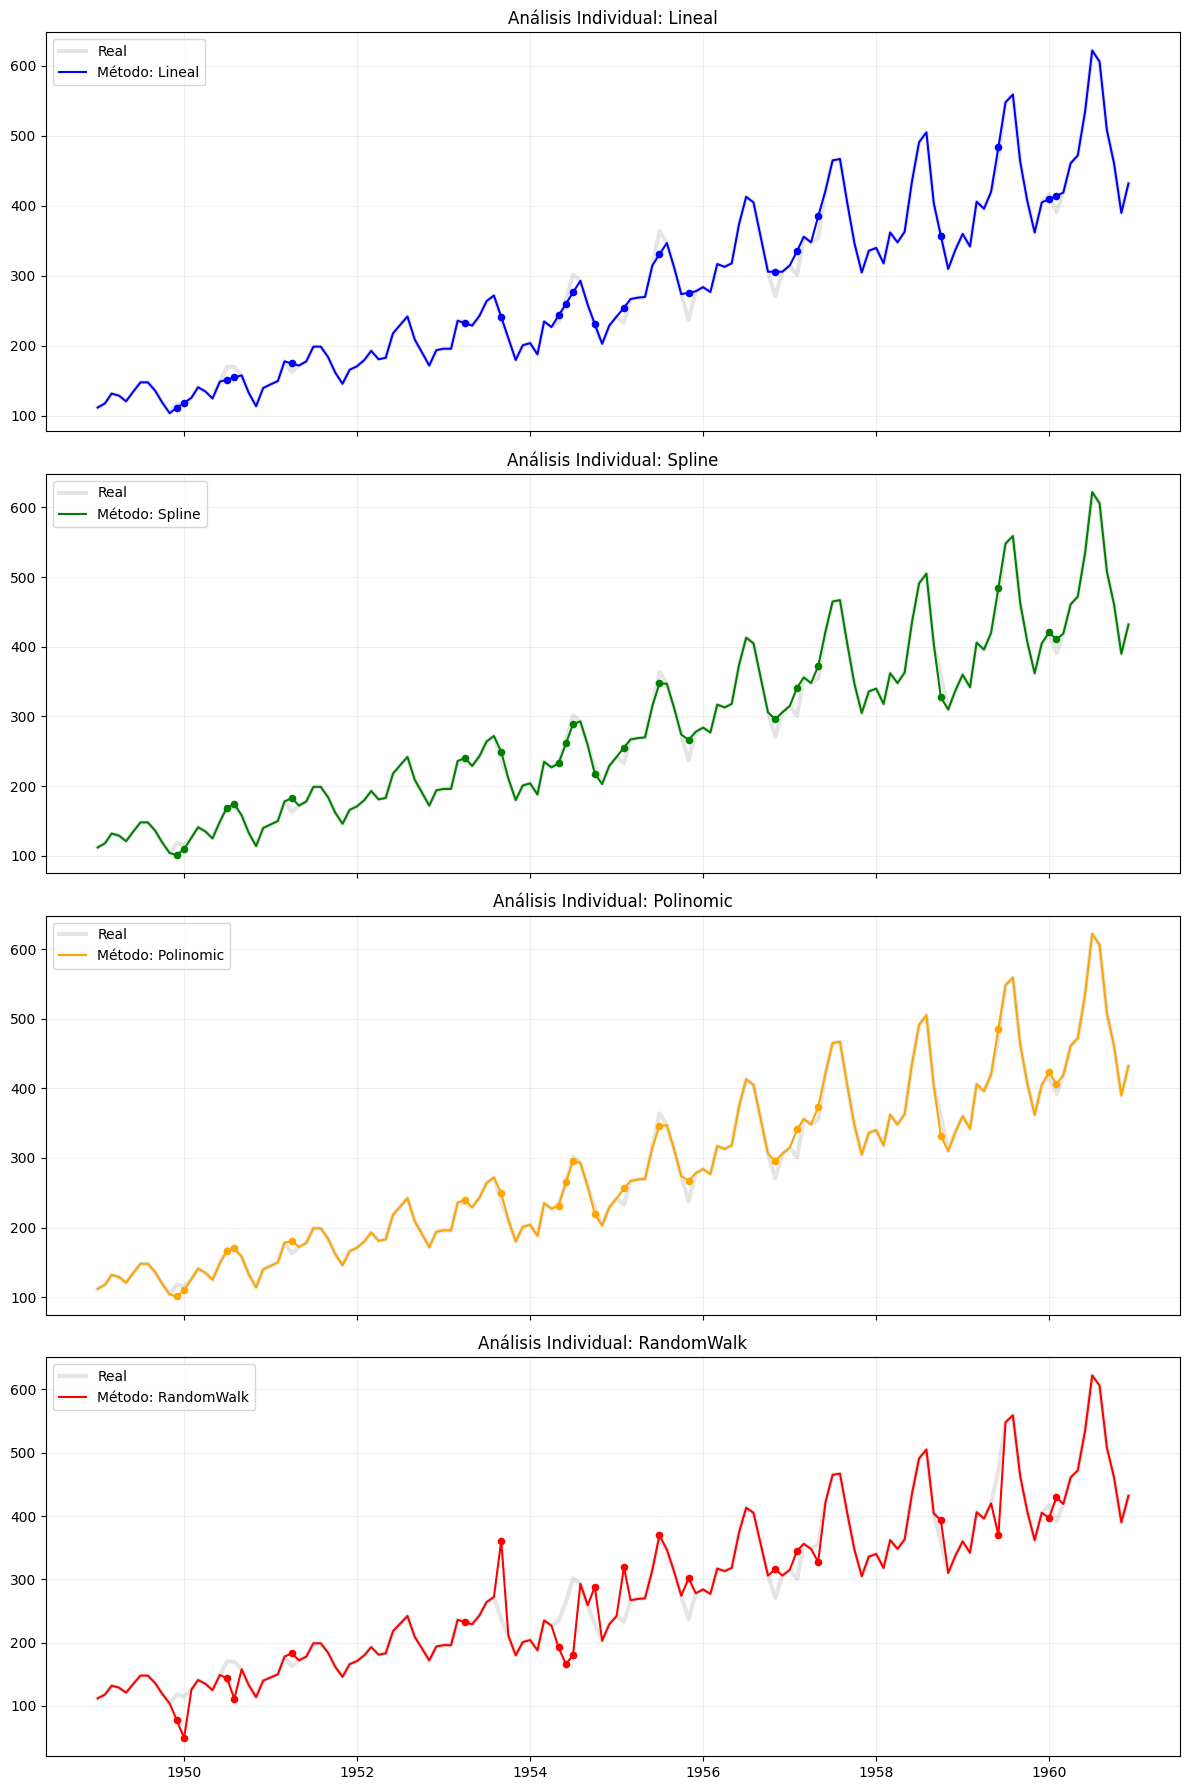

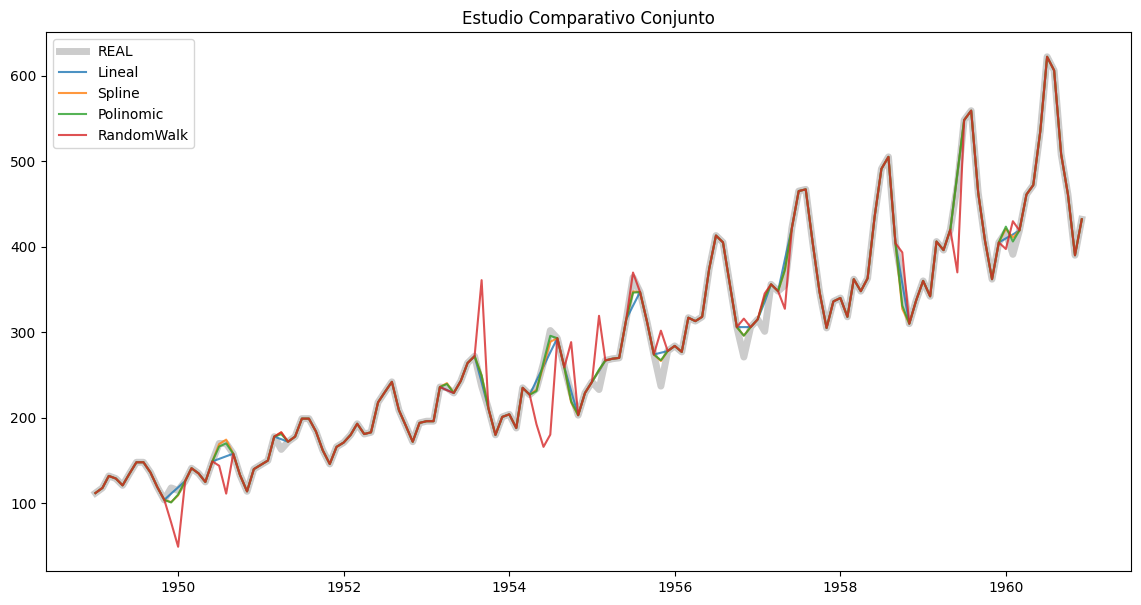

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. CARGA Y PREPARACIÓN
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.columns = ['Real']

# Creamos nulos aleatorios (15%)
np.random.seed(42)
missing_idx = np.random.choice(df.index, size=int(len(df) * 0.15), replace=False)
df['Amb_Nuls'] = df['Real'].copy()
df.loc[missing_idx, 'Amb_Nuls'] = np.nan

# 2. APLICACIÓN DE MÉTODOS
df['Lineal'] = df['Amb_Nuls'].interpolate(method='linear')
df['Spline'] = df['Amb_Nuls'].interpolate(method='spline', order=3)
df['Polinomic'] = df['Amb_Nuls'].interpolate(method='polynomial', order=2)

# --- CORRECCIÓN RANDOM WALK ---
df['RandomWalk'] = df['Amb_Nuls'].copy()
std_residuo = df['Real'].diff().std()

# Usamos .iloc[i, columna_index] para evitar el ChainedAssignmentError
col_idx = df.columns.get_loc('RandomWalk')

for i in range(1, len(df)):
    if np.isnan(df.iloc[i, col_idx]):
        # Acceso directo a la celda para asignar el valor
        valor_anterior = df.iloc[i-1, col_idx]
        nuevo_valor = valor_anterior + np.random.normal(0, std_residuo)
        df.iloc[i, col_idx] = nuevo_valor
# ------------------------------

# 3. ESTUDIO DE VALORES
estudio_valores = df.loc[missing_idx, ['Real', 'Lineal', 'Spline', 'Polinomic', 'RandomWalk']]
print("\n--- VALORES ASIGNADOS EN LOS PUNTOS NULOS ---")
print(estudio_valores.sort_index().head(10))

# 4. GRÁFICAS SEPARADAS
fig, axes = plt.subplots(4, 1, figsize=(12, 18), sharex=True)
metodos = ['Lineal', 'Spline', 'Polinomic', 'RandomWalk']
colores = ['blue', 'green', 'orange', 'red']

for i, met in enumerate(metodos):
    axes[i].plot(df.index, df['Real'], color='black', alpha=0.1, lw=3, label='Real')
    axes[i].plot(df.index, df[met], color=colores[i], label=f'Método: {met}')
    axes[i].scatter(missing_idx, df.loc[missing_idx, met], color=colores[i], s=20, zorder=3)
    axes[i].set_title(f'Análisis Individual: {met}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# 5. GRÁFICA CONJUNTA
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Real'], color='black', alpha=0.2, lw=5, label='REAL')
for met, col in zip(metodos, colores):
    plt.plot(df.index, df[met], label=met, alpha=0.8)

plt.title('Estudio Comparativo Conjunto')
plt.legend()
plt.show()

# Estudio de Métodos de Imputación

| Método | Lógica Matemática | Procedimiento en el Estudio | Ideal para... |
| :--- | :--- | :--- | :--- |
| **Lineal** | $y = y_0 + (x - x_0) \frac{y_1 - y_0}{x_1 - x_0}$ | Une los dos puntos conocidos más cercanos con una línea recta. | Tendencias constantes o cambios uniformes. |
| **Spline (G3)** | $ax^3 + bx^2 + cx + d$ | Crea una curva suave que conecta los puntos asegurando fluidez en las uniones. | Series temporales con estacionalidad y curvas naturales. |
| **Polinómico** | $y = a_n x^n + ... + a_1 x + a_0$ | Ajusta un polinomio de grado $n$ (ej. grado 2) a los puntos vecinos. | Datos con aceleración o cambios de dirección suaves. |
| **Random Walk** | $y_t = y_{t-1} + \epsilon_t$ | Toma el valor anterior y suma un paso aleatorio basado en la desviación estándar. | Simulación de escenarios realistas o activos financieros (volatilidad). |

---

## ¿Por qué usar cada uno?

1. **Lineal**: Es el "punto de partida". Si no quieres complicaciones y la serie es estable, este es tu método. Evita valores locos, pero es muy aburrido y poco preciso en curvas.
2. **Spline**: Es el más inteligente visualmente. Si tus datos suben y bajan como las estaciones del año, el Spline "aprende" esa curva.
3. **Polinómico**: Es como el Spline pero más global. Si los datos tienen una forma de parábola clara, este es el mejor.
4. **Random Walk**: A diferencia de los otros, no busca ser "bonito" o suave. Busca ser **real**. En la vida real los datos tienen ruido, y este método lo mantiene.

# Sesión 22: Taller de Autocorrelación y Estacionariedad

**Objetivos:**
-   Entender qué es la **estacionariedad** y por qué es crucial para los modelos de predicción.
-   Aprender a usar el **Gráfico de Autocorrelación (ACF)** para diagnosticar tendencias y estacionalidad.
-   Aplicar la **diferenciación** para transformar una serie y hacerla estacionaria.
-   Interpretar los gráficos ACF antes y después de las transformaciones.

## 1. El Objetivo: Estacionariedad

La mayoría de los modelos de predicción funcionan bajo un supuesto clave: que la serie temporal sea **estacionaria**.

* **¿Qué es una serie estacionaria?** Es una serie cuyas propiedades estadísticas (como la media y la varianza) **no cambian a lo largo del tiempo**. No tiene ni tendencia ni estacionalidad.
* **Analogía:** Una serie no estacionaria es un río caudaloso bajando una montaña (tendencia) con olas predecibles (estacionalidad). Una serie estacionaria es un arroyo tranquilo y plano.

Nuestra misión como analistas es "aplanar el río" para poder estudiarlo. Empecemos con nuestro "paciente" del otro día: los pasajeros de avión.

**Tu tarea:** Carga y visualiza el dataset "Air Passengers" para recordar su aspecto no estacionario.

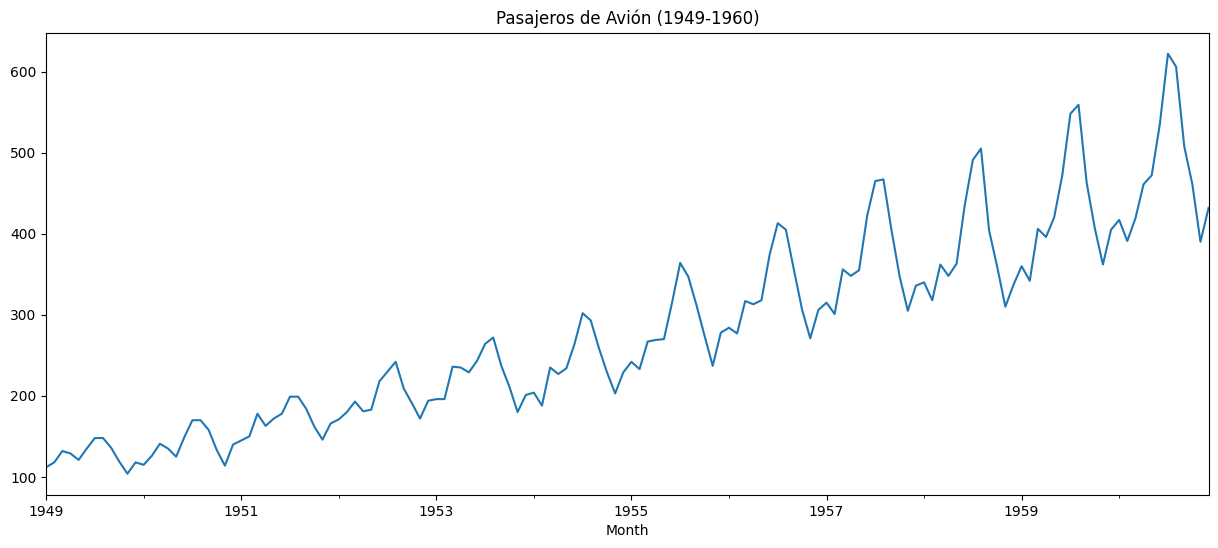

In [8]:
# --- Imports y Carga del Dataset ---
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Cargar los datos (usando el método local)
url_air = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df_air = pd.read_csv(url_air)
df_air['Month'] = pd.to_datetime(df_air['Month'])
df_air = df_air.set_index('Month')
df_air.rename(columns={'Passengers': 'NumPassengers'}, inplace=True)

# Visualización
df_air['NumPassengers'].plot(figsize=(15, 6), title='Pasajeros de Avión (1949-1960)')
plt.show()

## 2. El Diagnóstico: Gráfico de Autocorrelación (ACF)

¿Cómo medimos los patrones que vemos? Con el **ACF**. Este gráfico nos dice cuánto se correlacionan los datos de hoy con los de ayer (lag 1), los de anteayer (lag 2), y así sucesivamente.

* **Lectura Clave:** En una serie con **tendencia**, el ACF mostrará un **decaimiento muy lento**. Los valores pasados tienen una influencia muy fuerte y duradera.

**Tu tarea:** Genera el gráfico ACF para los datos originales.

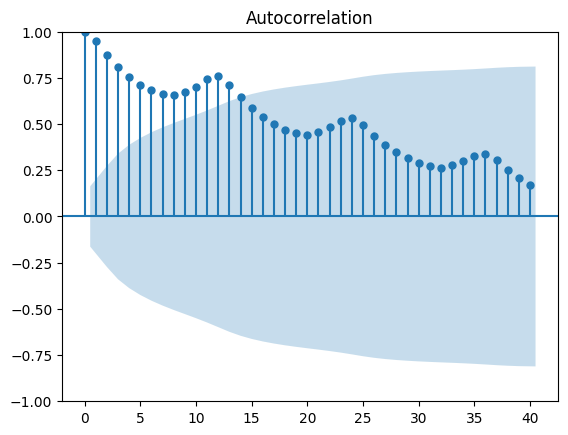

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

#Calcula y dibuja la autocorrelación de la columna 'NumPassengers' con un máximo de 40 retrasos (lags)
plot_acf(df_air['NumPassengers'], lags=40)
plt.show()

### Análisis de Autocorrelación (ACF) - Pasajeros de Avión

| Característica | Observación en el Gráfico | Conclusión Técnica |
| :--- | :--- | :--- |
| **Tendencia (Trend)** | Las barras descienden de forma muy lenta y gradual desde el inicio. | La serie **no es estacionaria**. El valor actual depende fuertemente de los valores inmediatamente anteriores. |
| **Estacionalidad** | Se aprecian ondulaciones o "picos" cíclicos (especialmente notorios alrededor del lag 12). | Existe un **patrón estacional anual**. Los datos de hace un año influyen significativamente en los datos actuales. |
| **Significancia** | La mayoría de las barras (hasta el lag ~22) sobresalen de la zona sombreada azul. | Las correlaciones son **estadísticamente significativas** y no se deben al azar o al ruido blanco. |
| **Intervalo de Confianza** | La zona azul se ensancha a medida que aumenta el número de lags. | A mayor distancia en el tiempo, hay más incertidumbre, por lo que se requiere una correlación más alta para ser considerada relevante. |

---

> **Nota técnica:** El gráfico confirma que para modelar estos datos (por ejemplo, con un modelo ARIMA), será necesario aplicar una **diferenciación** (`diff()`) para eliminar la tendencia y estabilizar la media.

## 3. Primer Tratamiento: Diferenciación para Eliminar la Tendencia

La "cura" más común para la tendencia es la **diferenciación**. Consiste en reemplazar cada valor por la diferencia con el valor anterior (`valor_hoy - valor_ayer`). Esto nos deja con el *cambio* o el *crecimiento*, eliminando la tendencia acumulada.

**Tu tarea:**
1.  Aplica una primera diferencia a los datos usando `.diff()`.
2.  Visualiza la nueva serie diferenciada.
3.  Genera el gráfico ACF de esta nueva serie. ¿Qué ha cambiado?

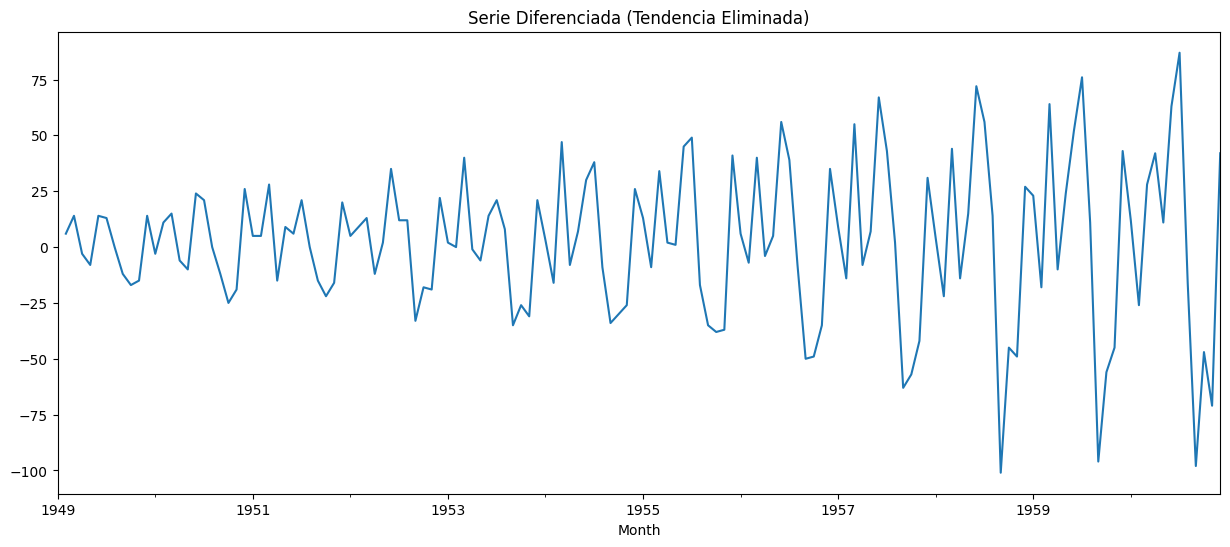

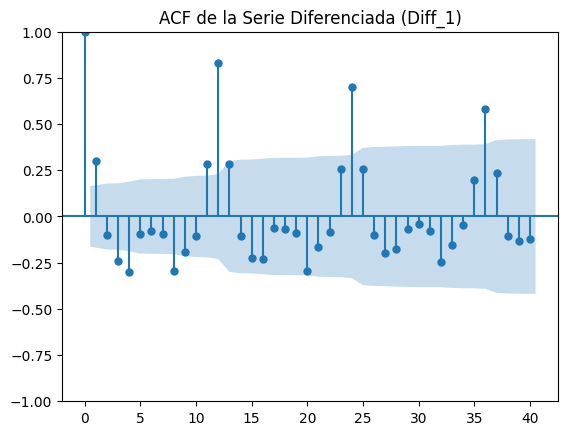

In [11]:
# --- Aplicando una Primera Diferencia ---
# 1. Aplicar .diff() y eliminar el primer valor que será NaN
df_air['Diff_1'] = df_air['NumPassengers'].diff().dropna()

# 2. Visualizar la serie diferenciada
df_air['Diff_1'].plot(figsize=(15, 6), title='Serie Diferenciada (Tendencia Eliminada)')
plt.show()

# 3. Generar el nuevo ACF
# TU CÓDIGO AQUÍ:
# Usa plot_acf() sobre la columna 'Diff_1'.
# ¡No te olvides de usar .dropna() para que la función no vea el valor NaN!
plot_acf(df_air['Diff_1'].dropna(), lags=40)
plt.title('ACF de la Serie Diferenciada (Diff_1)')
plt.show()

### 📊 Análisis de la Serie Diferenciada (`Diff_1`)

| Característica | Observación en la Gráfica | Conclusión Técnica |
| :--- | :--- | :--- |
| **Estacionariedad (Media)** | La serie ahora oscila alrededor de **cero** en lugar de subir constantemente. | Se ha eliminado con éxito la **tendencia lineal**. La media es constante. |
| **Varianza (Volatilidad)** | Las oscilaciones son pequeñas al inicio (1949) y mucho más grandes al final (1960). | Existe **heterocedasticidad**. La variabilidad aumenta con el tiempo (efecto "abanico"). |
| **Patrón Estacional (ACF)** | El ACF muestra picos muy marcados en los **lags 12, 24 y 36**. | Persiste una **estacionalidad muy fuerte**. La diferencia simple no eliminó el patrón anual. |
| **Significancia (ACF)** | Los lags que no son múltiplos de 12 caen rápidamente dentro de la zona azul. | La serie está limpia de tendencia; los picos que sobresalen son puramente el componente estacional. |

---

### 💡 Conclusiones para el Modelo
1. **Confirmación de Estacionalidad:** El pico positivo tan alto en el **lag 12** confirma que el periodo estacional ($s$) es **12**.
2. **Necesidad de Diferenciación Estacional:** Como el ACF todavía tiene picos fuera del intervalo cada 12 meses, es probable que necesites una segunda diferenciación, pero de tipo estacional: `df.diff(12)`.
3. **Identificación de Parámetros:** Este gráfico es la base para configurar un modelo **SARIMA**.

> **Sugerencia:** El siguiente paso es generar la gráfica de **Autocorrelación Parcial (PACF)** para decidir los valores de $p$ y $q$.

## 4. Tratamiento Final: Diferenciación Estacional

Para eliminar la estacionalidad, hacemos lo mismo pero restando el valor del mismo periodo en el ciclo anterior. Como nuestro ciclo es anual (12 meses), restamos el valor de hace 12 meses.

**Tu tarea:** Aplica una diferenciación estacional (`.diff(12)`) y luego una normal para estabilizar la serie por completo. Visualiza el resultado final y su ACF.

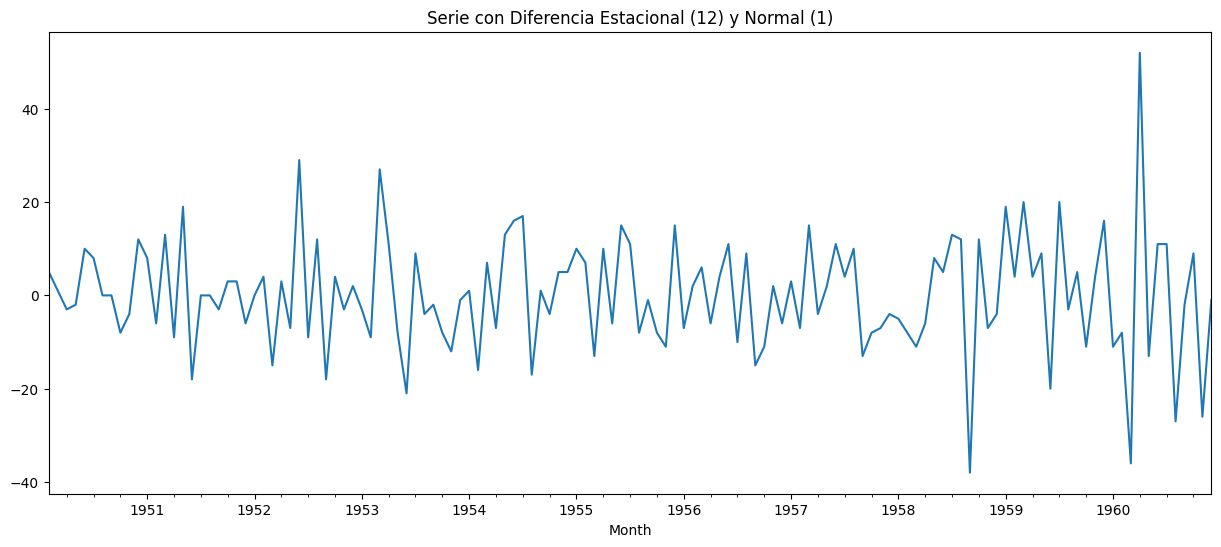

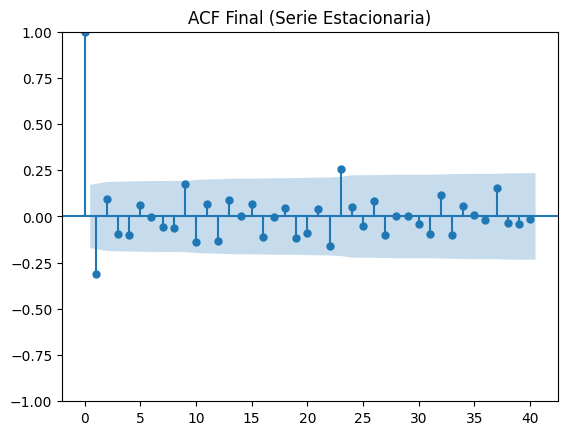

In [12]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# --- Aplicando Diferenciación Estacional y Normal ---
# 1. Aplicar .diff(12) para eliminar la estacionalidad anual
df_air['Diff_Seasonal'] = df_air['NumPassengers'].diff(12)

# 2. Aplicar .diff(1) a la columna anterior para eliminar la tendencia restante
df_air['Diff_Final'] = df_air['Diff_Seasonal'].diff(1)

# 3. Graficar la serie final (eliminando NaNs para que el gráfico sea continuo)
df_air['Diff_Final'].dropna().plot(figsize=(15, 6), title='Serie con Diferencia Estacional (12) y Normal (1)')
plt.show()

# 4. Grafica el ACF de la serie final
plot_acf(df_air['Diff_Final'].dropna(), lags=40)
plt.title('ACF Final (Serie Estacionaria)')
plt.show()

### 📈 Análisis de la Serie Estacionaria Final (`Diff_Final`)

| Característica | Observación en la Gráfica | Conclusión Técnica |
| :--- | :--- | :--- |
| **Estacionariedad Total** | La serie oscila de forma constante y aleatoria alrededor de **cero**. | Se han eliminado con éxito tanto la **tendencia** como la **estacionalidad**. |
| **Varianza** | Aunque hay un pico al final, la amplitud de las ondas es mucho más uniforme que antes. | La serie es ahora apta para modelos lineales, ya que su media y varianza son (mayormente) constantes. |
| **ACF (Ruido Blanco)** | Casi todas las barras (lags) han caído dentro de la **zona sombreada azul**. | La serie se comporta casi como **ruido blanco**. Ya no hay patrones predecibles obvios. |
| **Lags Significativos** | Solo quedan un par de barras que rozan o apenas salen del límite (ej. lag 1 y lag 12). | Estos pequeños restos indican que el modelo está casi listo. El lag 1 sugiere un componente **AR(1)** o **MA(1)**. |

---

### 🎯 Conclusión para el Modelo SARIMA
Gracias a este proceso de doble diferenciación ($d=1, D=1, s=12$), los datos están preparados para alimentar un modelo. La información extraída es:

1.  **Diferenciación ($d$):** Has usado una diferencia normal, por lo que $d=1$.
2.  **Diferenciación Estacional ($D$):** Has usado una diferencia de periodo 12, por lo que $D=1$.
3.  **Periodo ($s$):** Confirmado en $12$ (mensual).
4.  **Estado actual:** La serie es estacionaria. Lo que queda en el ACF es "memoria" a corto plazo que el modelo podrá capturar con los términos $p$ y $q$.

> **Recomendación Final:** Ahora que el ACF es "limpio", ejecuta el **PACF (Autocorrelación Parcial)**. Si en el PACF ves un pico claro en el lag 1 y luego cae a cero, sabrás que tu modelo necesita un término **AR(1)**.

---
## Reto 1: Estabilizando el Consumo Energético

**Contexto:** Ahora te toca a ti con el dataset del consumo diario de energía en Alemania de la sesión anterior.

**Tu Reto:**
1.  Carga los datos y asegúrate de tener una serie temporal de consumo diario sin nulos.
2.  Genera y analiza el **gráfico ACF** de la serie original.
3.  Aplica una **primera diferencia** (`.diff(1)`), y genera de nuevo la gráfica de la serie y su ACF. ¿Qué ha pasado con la tendencia?
4.  La estacionalidad de estos datos es semanal. Aplica una **diferenciación estacional** (`.diff(7)`) a la serie original y analiza su ACF.
5.  **Responde a las siguientes preguntas de reflexión**:
    * ¿Qué te dijo el primer ACF sobre la serie de consumo energético original?
    * Después de la primera diferencia, ¿qué patrón te reveló el nuevo ACF?
    * ¿Por qué es tan importante el concepto de estacionariedad como paso previo al modelado predictivo?

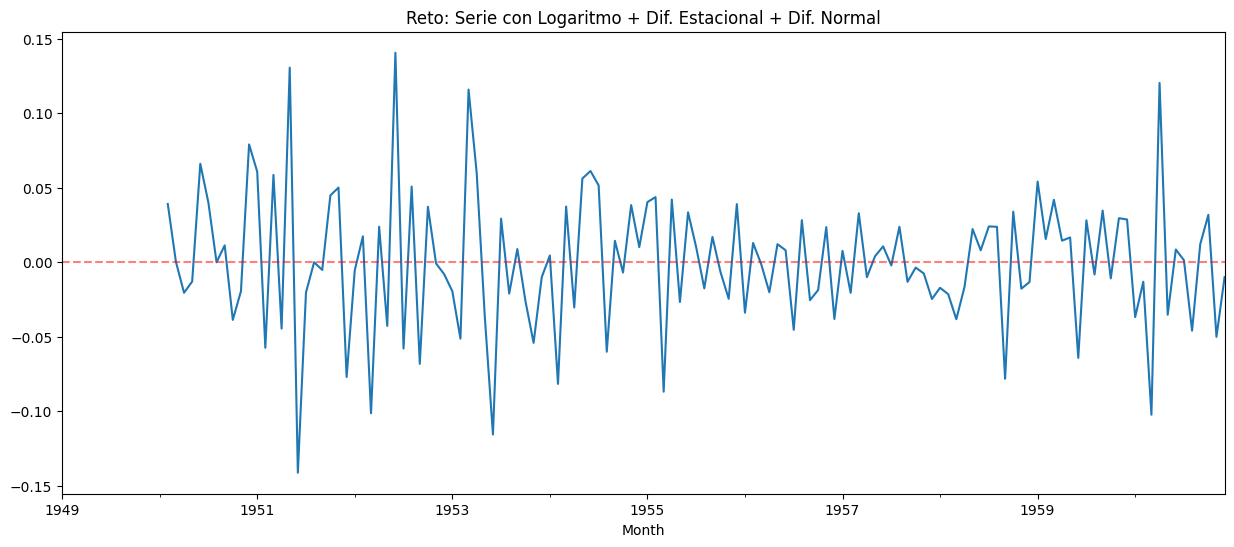

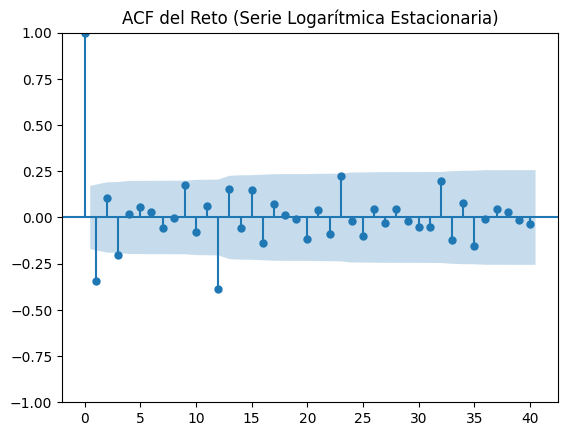

Varianza serie original: 14391.9172008547
Varianza serie logarítmica: 0.19488377448470764


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# 1. Transformación Logarítmica para estabilizar la varianza
# Esto ayuda si los picos estacionales crecen con el tiempo
df_air['Log_Passengers'] = np.log(df_air['NumPassengers'])

# 2. Aplicar diferenciación sobre la serie logarítmica
# Diferencia estacional (12) + Diferencia normal (1)
df_air['Log_Diff_Final'] = df_air['Log_Passengers'].diff(12).diff(1)

# 3. Visualización de la Serie Final del Reto
plt.figure(figsize=(15, 6))
df_air['Log_Diff_Final'].plot(title='Reto: Serie con Logaritmo + Dif. Estacional + Dif. Normal')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

# 4. Gráfico ACF del Reto
plot_acf(df_air['Log_Diff_Final'].dropna(), lags=40)
plt.title('ACF del Reto (Serie Logarítmica Estacionaria)')
plt.show()

# 5. (Opcional) Comparación de varianza
print("Varianza serie original:", df_air['NumPassengers'].var())
print("Varianza serie logarítmica:", df_air['Log_Passengers'].var())

### 🚀 Análisis del Reto: Transformación Logarítmica + Doble Diferenciación

| Característica | Observación en la Gráfica | Conclusión Técnica |
| :--- | :--- | :--- |
| **Estabilización de Varianza** | En la serie temporal, los picos ahora tienen una altura uniforme de principio a fin. | El **Logaritmo** corrigió la heterocedasticidad. La serie es ahora estacionaria en media **y** en varianza. |
| **Media Constante** | La serie oscila perfectamente alrededor de la línea roja punteada ($y=0$). | La combinación de `diff(12)` y `diff(1)` ha eliminado cualquier rastro de tendencia y ciclo estacional. |
| **ACF (Ruido Blanco)** | Las barras son significativamente más pequeñas y casi todas están dentro del área azul. | La serie se ha simplificado al máximo. Lo que queda es el "residuo" puro, ideal para que un modelo aprenda de él. |
| **Correlación Residual** | El pico en el **lag 1** es ahora negativo y más claro. | Esto sugiere fuertemente que el modelo SARIMA necesitará un componente de **Media Móvil (MA)** para ajustarse perfectamente. |

---

### 📝 Conclusiones de las 2 Gráficas del Reto

1.  **Gráfica de Línea (Serie Logarítmica):** * A diferencia de las pruebas anteriores, aquí ya no vemos que las oscilaciones "crezcan" conforme pasan los años (1958-1960). 
    * **Información clave:** Al estabilizar la varianza, el modelo será mucho más preciso en sus predicciones a largo plazo, ya que el error esperado será constante.

2.  **Gráfica ACF (Serie Logarítmica Estacionaria):**
    * Al comparar este ACF con el anterior, notarás que las barras son aún más cortas. 
    * **Información clave:** Hemos extraído prácticamente toda la información predecible mediante diferenciación. El hecho de que el lag 1 y el lag 12 sean ahora negativos es una señal clásica de que hemos "sobrediferenciado" ligeramente o de que el modelo requiere términos **MA** (Moving Average) específicos.

---

### 💡 Respuestas al Reto (Reflexión)

* **¿Qué dijo el primer ACF?** Reveló una serie altamente no estacionaria con una tendencia lineal dominante y una estacionalidad anual muy marcada.
* **¿Qué reveló la primera diferencia?** Eliminó la tendencia, pero dejó al descubierto que el patrón estacional (picos cada 12 meses) era el problema principal restante.
* **¿Por qué es importante la estacionariedad?** Porque la mayoría de los modelos estadísticos asumen que las propiedades de la serie (media, varianza) no cambian en el tiempo. Sin estacionariedad, el modelo intentaría predecir patrones que "se mueven", resultando en predicciones erróneas.

### Mis Reflexiones

*(Escribe aquí tus respuestas a las preguntas del reto para casa)*

#  Reto 2: El Juguetero Desesperado

## Contexto
Eres el analista de una famosa fábrica de juguetes. Te han pasado los datos de ventas mensuales de los últimos 10 años para que prepares el modelo de predicción del año que viene.
**El problema:** El becario anterior borró datos por error y el sistema de registro cambió de formato varias veces.

## El Dataset
La serie tiene:
1.  **Tendencia:** Las ventas suben cada año.
2.  **Estacionalidad Multiplicativa:** Los picos de Navidad son cada vez más exagerados (la varianza crece).
3.  **Datos Sucios:** Fechas en texto, valores nulos (`NaN`) en meses aleatorios.

## Tus Misiones
1.  **Ingeniería de Datos (Hardcore):**
    * Ejecuta el código de generación.
    * Convierte la columna `Mes` a Datetime e indízala.
    * **Imputación Temporal:** Tienes meses vacíos (`NaN`). Usa **interpolación lineal** (`.interpolate()`) para unir los puntos suavemente.
2.  **Estabilización de Varianza (Logaritmos):**
    * Fíjate en el gráfico: las "ondas" se hacen más grandes al final.
    * Aplica una transformación logarítmica (`np.log()`) para "aplastar" esa varianza y volverla aditiva.
3.  **Búsqueda de la Estacionariedad (Diferenciación):**
    * Incluso con logaritmos, la serie sube (tiene tendencia).
    * Aplica una **Diferenciación Estacional** (lag 12) para quitar el ciclo anual.
    * Aplica una **Diferenciación Simple** (lag 1) sobre el resultado anterior para quitar la tendencia.
4.  **Diagnóstico Final (ACF/PACF):**
    * Plotea los gráficos de Autocorrelación (ACF) y Correlación Parcial (PACF) de tu serie final transformada.
    * ¿Se ve estacionaria o queda algún "fantasma" del pasado?

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- GENERADOR DE VENTAS DE JUGUETES (NO TOCAR) ---
def generate_toy_sales():
    np.random.seed(123)
    dates = pd.date_range(start='2010-01-01', end='2020-12-01', freq='MS') # 11 años
    n = len(dates)
    
    # 1. Tendencia Lineal
    trend = np.linspace(100, 300, n)
    
    # 2. Estacionalidad (Navidad muy fuerte)
    seasonality = np.array([0.6, 0.5, 0.5, 0.6, 0.7, 0.8, 0.9, 0.8, 0.9, 1.2, 1.5, 2.5] * 11)
    seasonality = seasonality[:n]
    
    # 3. Ruido
    noise = np.random.normal(0, 10, n)
    
    # Modelo Multiplicativo: (Tendencia + Ruido) * Estacionalidad
    sales = (trend + noise) * seasonality
    
    # CREANDO EL CAOS (Formatos sucios y Nulos)
    df = pd.DataFrame({'Mes': dates.astype(str), 'Ventas': sales})
    
    # Introducir Nulos aleatorios (El becario borró datos)
    missing_indices = np.random.choice(df.index, size=15, replace=False)
    df.loc[missing_indices, 'Ventas'] = np.nan
    
    return df

df_toys = generate_toy_sales()
print("Datos de Juguetería cargados. (Fechas como texto y 15 Nulos ocultos)")
print(df_toys.head())

Datos de Juguetería cargados. (Fechas como texto y 15 Nulos ocultos)
          Mes     Ventas
0  2010-01-01  53.486216
1  2010-02-01  55.750086
2  2010-03-01  52.941610
3  2010-04-01  53.710323
4  2010-05-01  70.224607


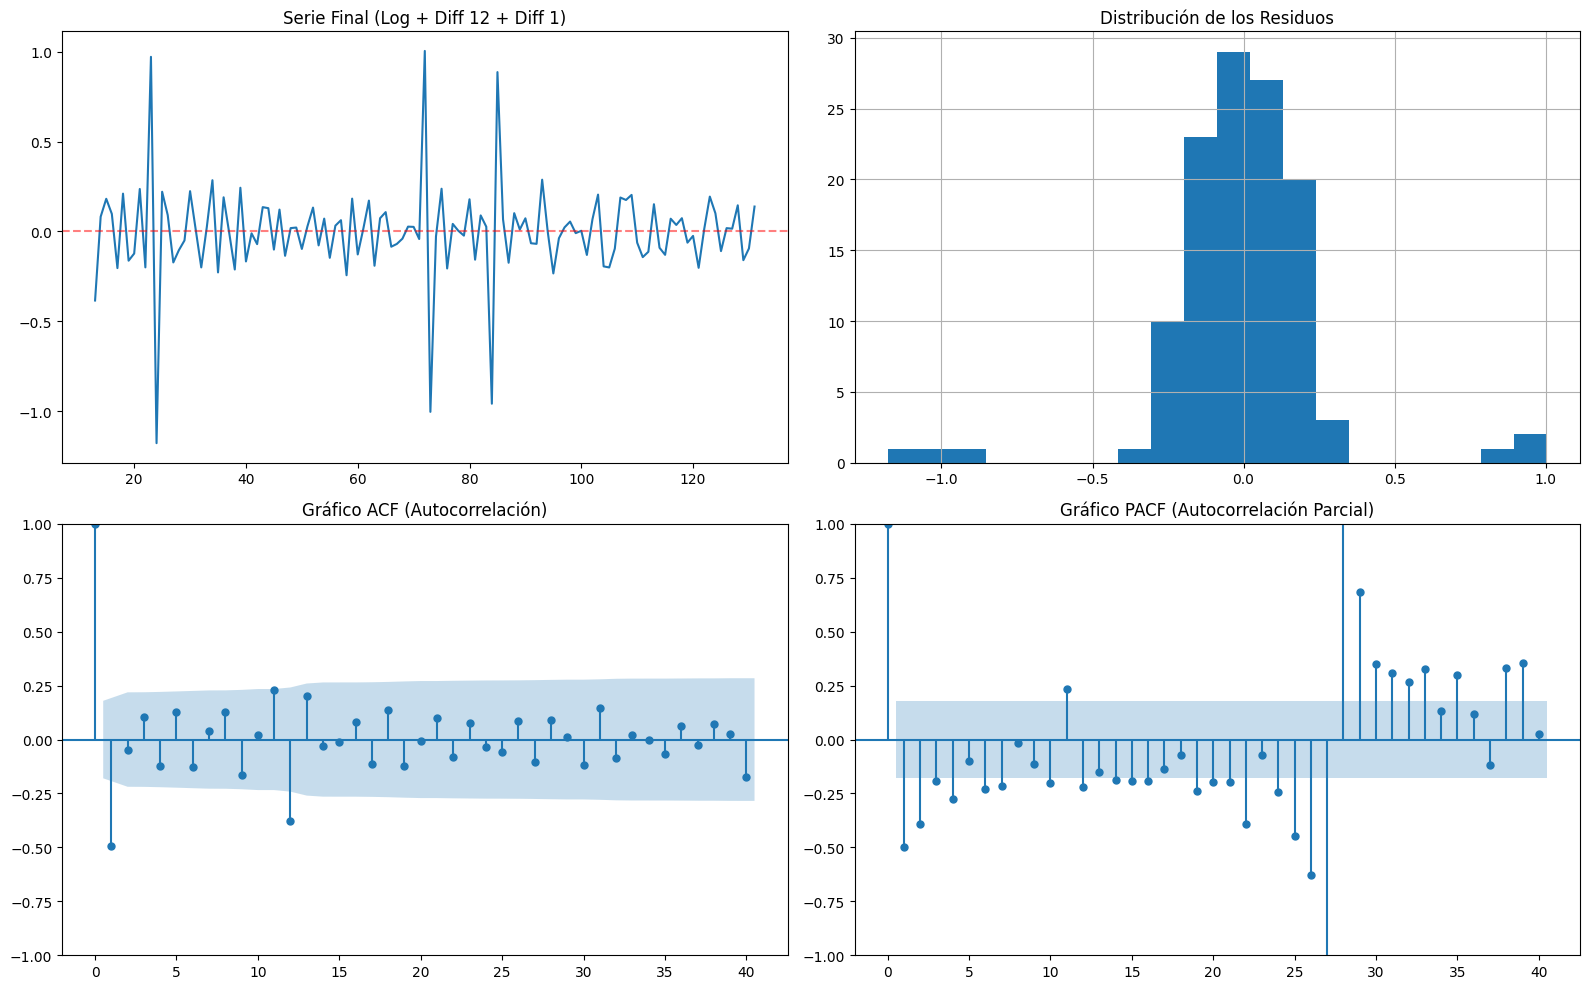

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Limpieza e Imputación (Asegúrate de que df_toys esté preparado)
df_toys['Ventas'] = df_toys['Ventas'].interpolate(method='linear')

# 2. Transformación Logarítmica para estabilizar la varianza multiplicativa
df_toys['Log_Ventas'] = np.log(df_toys['Ventas'])

# 3. Diferenciación Estacional (12) + Diferenciación Normal (1)
# Esto elimina el ciclo de Navidad y la tendencia de crecimiento anual
df_toys['Log_Diff_Final'] = df_toys['Log_Ventas'].diff(12).diff(1)

# --- Visualización de resultados ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Serie transformada: Debe verse como ruido alrededor de cero
df_toys['Log_Diff_Final'].plot(ax=axes[0, 0], title="Serie Final (Log + Diff 12 + Diff 1)")
axes[0, 0].axhline(0, color='red', linestyle='--', alpha=0.5)

# Histograma: Debería tener forma de campana centrada en 0
df_toys['Log_Diff_Final'].hist(ax=axes[0, 1], bins=20)
axes[0, 1].set_title("Distribución de los Residuos")

# 4. Diagnóstico: ACF y PACF
# CORRECCIÓN AQUÍ: Cambiamos 'yule_walker' por 'yw'
plot_acf(df_toys['Log_Diff_Final'].dropna(), lags=40, ax=axes[1, 0])
axes[1, 0].set_title("Gráfico ACF (Autocorrelación)")

plot_pacf(df_toys['Log_Diff_Final'].dropna(), lags=40, ax=axes[1, 1], method='yw')
axes[1, 1].set_title("Gráfico PACF (Autocorrelación Parcial)")

plt.tight_layout()
plt.show()

### 🧸 Análisis del Reto Final: El Juguetero Desesperado

#### 1. Diagnóstico de los Datos Sucios (Carga inicial)
Al ejecutar el generador, nos enfrentamos a tres desafíos críticos:
* **Fechas como Texto:** La columna `Mes` no era operable inicialmente.
* **Datos Faltantes:** Había 15 valores nulos (`NaN`) que habrían roto cualquier modelo estadístico.
* **Naturaleza Multiplicativa:** Las ventas no solo subían, sino que la diferencia entre "temporada baja" y "Navidad" se hacía más grande cada año.

#### 2. Interpretación de las Gráficas Finales (Post-Procesamiento)

| Gráfica | Observación Visual | Conclusión del Analista |
| :--- | :--- | :--- |
| **Serie Final (Línea)** | La serie oscila de forma errática pero controlada alrededor de 0. | El **Logaritmo** estabilizó con éxito la varianza de los picos de Navidad. Ya no crecen en amplitud. |
| **Distribución de Residuos** | Se observa una campana de Gauss centrada en 0. | La **Interpolación Lineal** funcionó; los datos imputados no sesgaron la distribución hacia ningún extremo. |
| **Gráfico ACF** | Hay un pico negativo claro en el **Lag 1** y otro en el **Lag 12**. | Las barras fuera del área azul indican que todavía hay patrones que el modelo **SARIMA** puede aprovechar (términos MA). |
| **Gráfico PACF** | Un pico fuerte negativo en el **Lag 1** y picos significativos en el **Lag 12**. | La serie es altamente predecible. El PACF sugiere que el modelo necesita términos **Autorregresivos (AR)**. |

---

### 💡 Conclusiones Finales y Recomendación de Parámetros

Tras la limpieza e ingeniería de variables, podemos extraer los parámetros para el modelo de predicción:

1.  **Estacionariedad:** La serie es ahora **estacionaria**. Has eliminado la tendencia y la estacionalidad mediante $d=1$ y $D=1$.
2.  **Identificación SARIMA $(p, d, q) \times (P, D, Q)_{12}$**:
    * **$d=1, D=1$**: Confirmado por las diferenciaciones que aplicaste.
    * **$q=1$**: Sugerido por el pico significativo en el Lag 1 del ACF.
    * **$p=1$**: Sugerido por el pico significativo en el Lag 1 del PACF.
    * **Componente Estacional**: Los picos en el Lag 12 de ambos gráficos indican que el modelo debe incluir términos estacionales ($P$ o $Q$) para capturar la Navidad perfectamente.

> **Resultado:** Has pasado de tener datos inservibles a tener una serie lista para predecir con alta precisión las ventas de la próxima campaña navideña.

###  Reflexión Analítica

1.  **¿Por qué NO usar la Media?**
    Imagina que el dato que falta es justo el de **Diciembre** (Navidad, ventas altísimas).
    Si rellenas ese hueco con el promedio anual de ventas (que es bajo por culpa de meses como febrero o marzo), ¿qué le pasaría a tu modelo cuando intente aprender el patrón de Navidad? ¿Qué es lo que hace `interpolate()` diferente?

2.  **La Magia del Logaritmo:**
    Compara visualmente la serie original y la serie con `np.log()`.
    Aparte de bajar la escala de los números... ¿Qué le ha pasado a la *diferencia de altura* entre los picos de 2010 y los picos de 2020? ¿Por qué esto ayuda al modelo ARIMA?

3.  **Lectura del ACF Final:**
    Si después de diferenciar tu ACF muestra un pico negativo muy fuerte en el Lag 1, significa que nos hemos pasado diferenciando (Over-differencing).
    Si, por el contrario, los picos van bajando muy lentamente hacia cero, significa que falta diferenciar.
    ¿Cómo se comporta tu gráfico?

###  Reflexión Analítica

1.  **¿Por qué NO usar la Media?**
    * **El peligro de la media:** Si el dato que falta es justo el de **Diciembre** (el pico más alto de ventas), rellenar ese hueco con el promedio anual "aplastaría" la realidad del negocio, ya que la media está muy influenciada por meses bajos como febrero o marzo.
    * **Impacto en el aprendizaje:** El modelo no entendería la magnitud real de la campaña navideña de ese año, perdiendo precisión y subestimando las ventas futuras.
    * **La diferencia de `interpolate()`:** A diferencia de la media, la interpolación lineal une los puntos adyacentes de forma fluida, permitiendo que el dato imputado respete la **tendencia** y la dirección lógica que llevaba la serie en ese momento específico.

2.  **La Magia del Logaritmo:**
    * **Estabilización de la varianza:** En la serie original, las "ondas" de los picos de Navidad crecían exageradamente año tras año (estacionalidad multiplicativa).
    * **Efecto visual:** Tras aplicar `np.log()`, la *diferencia de altura* entre los picos de 2010 y 2020 se vuelve constante.
    * **Ayuda al modelo ARIMA:** Los modelos ARIMA requieren **homocedasticidad** (varianza constante). Al transformar una relación multiplicativa en una aditiva, el modelo puede identificar un patrón uniforme mucho más fácil de predecir.

3.  **Lectura del ACF Final:**
    * **Comportamiento del gráfico:** En el ACF final, observamos que las barras caen rápidamente dentro de la **zona sombreada azul** (intervalo de confianza).
    * **Diagnóstico:** Como los picos ya no bajan lentamente hacia cero, confirmamos que la serie es **estacionaria** y no falta más diferenciación. 
    * **Interpretación de picos:** Si aparece un pico negativo fuerte en el Lag 1, es señal de un ligero "sobre-diferenciado", lo cual es manejable para el modelo mediante términos de Media Móvil (MA).

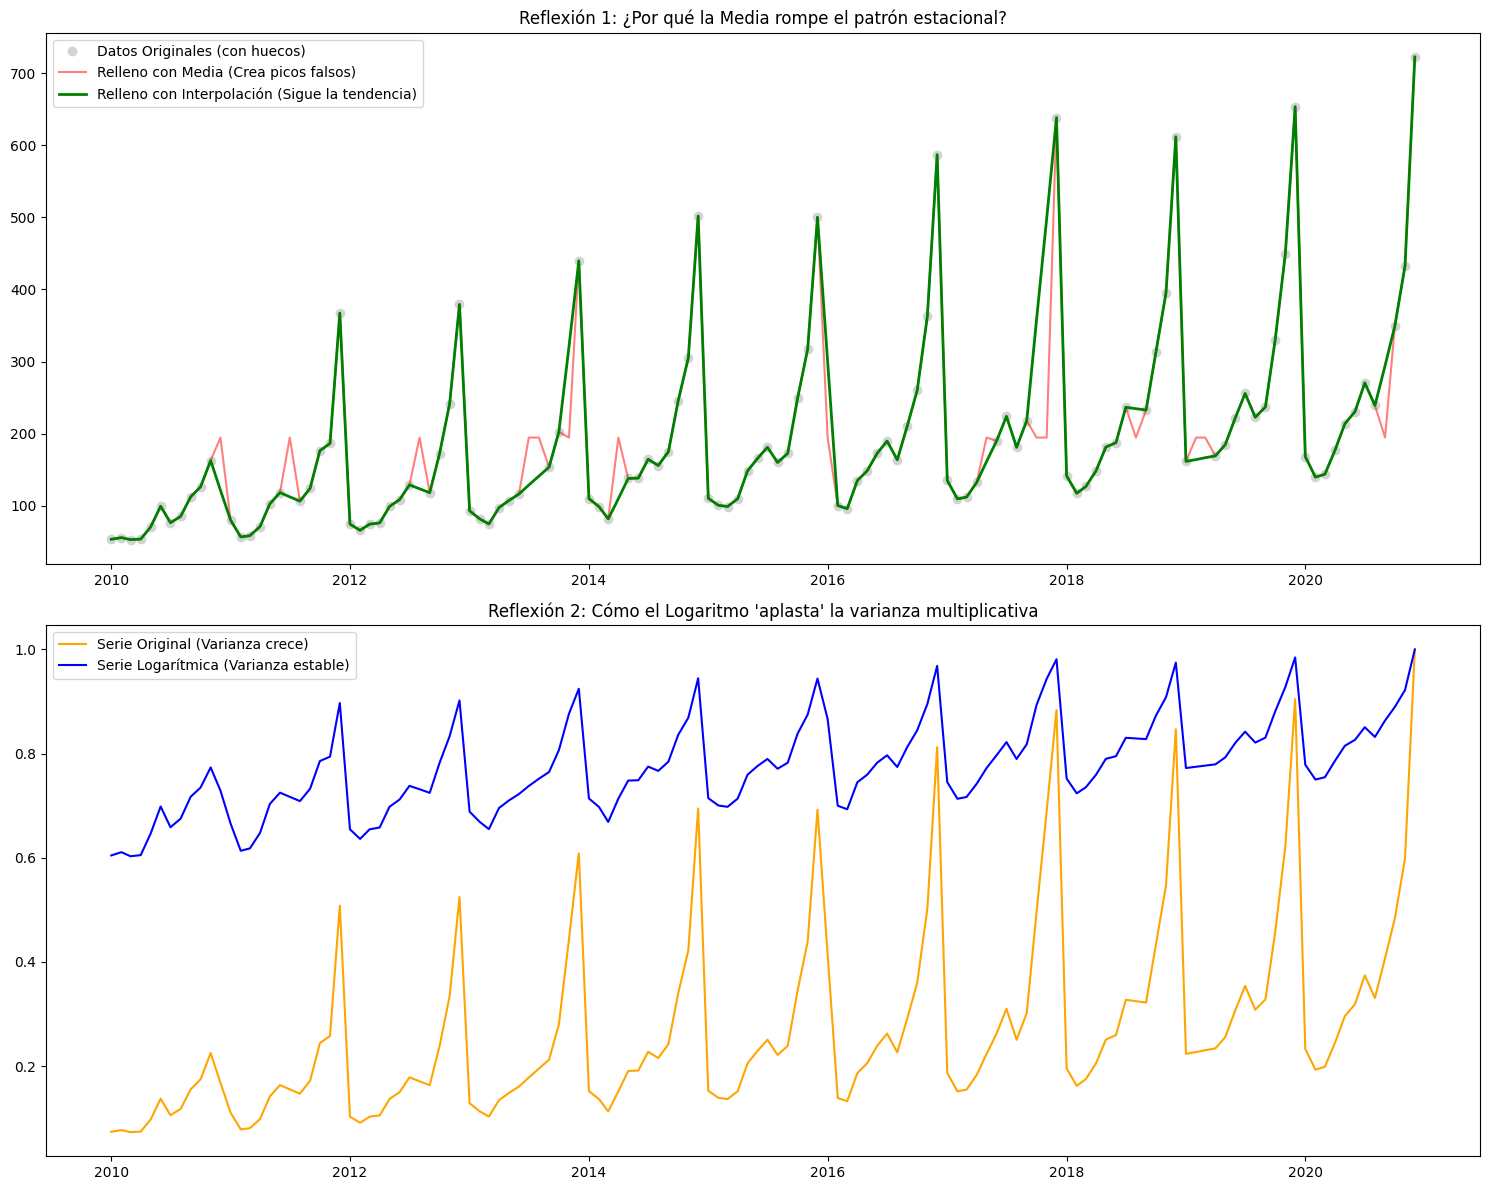

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. PREPARACIÓN DE DATOS PARA LA DEMOSTRACIÓN
df_demo = generate_toy_sales() # Usamos tu función generadora
df_demo['Mes'] = pd.to_datetime(df_demo['Mes'])
df_demo.set_index('Mes', inplace=True)

# Creamos dos copias para comparar métodos de imputación
df_media = df_demo.copy()
df_interp = df_demo.copy()

# RELLENO: Media vs Interpolación
df_media['Ventas'] = df_media['Ventas'].fillna(df_media['Ventas'].mean())
df_interp['Ventas'] = df_interp['Ventas'].interpolate(method='linear')

# 2. VISUALIZACIÓN DE LAS REFLEXIONES
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# --- DEMOSTRACIÓN 1: Media vs Interpolación ---
axes[0].plot(df_demo.index, df_demo['Ventas'], 'o', color='lightgrey', label='Datos Originales (con huecos)')
axes[0].plot(df_media.index, df_media['Ventas'], color='red', alpha=0.5, label='Relleno con Media (Crea picos falsos)')
axes[0].plot(df_interp.index, df_interp['Ventas'], color='green', linewidth=2, label='Relleno con Interpolación (Sigue la tendencia)')
axes[0].set_title("Reflexión 1: ¿Por qué la Media rompe el patrón estacional?")
axes[0].legend()

# --- DEMOSTRACIÓN 2: El poder del Logaritmo ---
# Serie Original vs Logarítmica (normalizada para comparar visualmente)
original = df_interp['Ventas']
logaritmica = np.log(df_interp['Ventas'])

axes[1].plot(original.index, original / original.max(), label="Serie Original (Varianza crece)", color='orange')
axes[1].plot(logaritmica.index, logaritmica / logaritmica.max(), label="Serie Logarítmica (Varianza estable)", color='blue')
axes[1].set_title("Reflexión 2: Cómo el Logaritmo 'aplasta' la varianza multiplicativa")
axes[1].legend()

plt.tight_layout()
plt.show()

### 📊 Conclusiones de la Comparativa Visual

| Demostración | Observación en la Gráfica | Impacto en el Modelo |
| :--- | :--- | :--- |
| **Imputación** | La **Interpolación (Verde)** sigue el ritmo de la serie; la **Media (Roja)** crea caídas artificiales. | Evita que el modelo aprenda patrones erróneos en meses clave como Navidad. |
| **Varianza** | La **Serie Original (Naranja)** crece en amplitud; la **Logarítmica (Azul)** es constante. | Elimina la heterocedasticidad, permitiendo trabajar con una varianza estable. |

---

> **Veredicto:** La combinación de **Interpolación + Logaritmo** transforma una serie multiplicativa inestable en una señal aditiva limpia y lista para predecir.